# Study 6: 4-D inference — (length_scale, mu_0, sigma, beta_speaker) via Laplace + VBMC

Study 6 uses **feature set 1** (16 train + 16 test features, 2d embedding — the set1 384d
row→feature alignment is unresolved, so 2d is the verified space). Three groups:

- **generic**: one generic statement per train feature (u=0 × 16)
- **specific**: one specific statement per the same train features (u=1 × 16) — specifics enter
  the existing RSA speaker as pragmatic soft evidence *against* kind-linkedness
- **baseline**: no statements (coherence field stays at the GP prior)

Model spec mirrors the study 9 canonical run (`model-study9-vbmc-laplace-beta.ipynb`):
Laplace marginal likelihood per group, 4-D VBMC over `phi4 = [log_ls, mu_0, log_sigma, log_beta]`,
per-feature Beta-mixture linking shapes PROFILED OUT at every eval
(`inference.run_vbmc_free_shapes_beta`). Results cached — delete files under
`results/study6-vbmc-laplace-beta/` to refit.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")

import sys
sys.path.insert(0, ".")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inference as inf     # import before other jax users (sets x64)
import studies68 as s68

MAX_EVALS = 400
RESULTS_DIR = os.path.join('results', 'study6-vbmc-laplace-beta')
os.makedirs(RESULTS_DIR, exist_ok=True)
inf.set_embed('2d')         # set1: only 2d coords are verified

geom, responses_cond = s68.load_study6()
J, test_feature_names = geom['J'], geom['test_feature_names']
CONDS = list(responses_cond.keys())
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in CONDS}
for c in CONDS:
    print(f"  {c:<9}: {int(responses_cond[c].shape[0])} participants  "
          f"mean rating={np.array(responses_cond[c]).mean():.3f}")

  generic  : 95 participants  mean rating=0.446
  specific : 90 participants  mean rating=0.260
  baseline : 99 participants  mean rating=0.360


## 1. Objective slice along beta

Summed `log Z` (fitted shapes) as a function of `beta_speaker` at the reference theta —
checks there is curvature in the beta direction before trusting the 4-D fit. Note beta is
informed by the training utterances of the generic AND specific groups here (study 9 only
had generics).

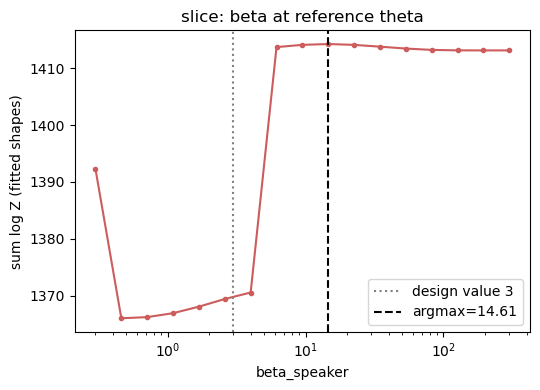

In [2]:
REF_LS, REF_MU, REF_SIGMA = 0.4, 0.0, 1.5
beta_grid = np.geomspace(0.3, 300.0, 17)
ll_beta_f = np.array([inf.total_log_lik_free_shapes(geom, responses_cond,
                                                    REF_LS, REF_MU, REF_SIGMA, beta_speaker=b)
                      for b in beta_grid])

plt.figure(figsize=(5.5, 4))
plt.plot(beta_grid, ll_beta_f, '-o', ms=3, color='indianred')
plt.axvline(inf.BETA_SPEAKER, color='gray', ls=':', label='design value 3')
plt.axvline(beta_grid[np.argmax(ll_beta_f)], color='k', ls='--',
            label=f'argmax={beta_grid[np.argmax(ll_beta_f)]:.2f}')
plt.xscale('log'); plt.xlabel('beta_speaker'); plt.ylabel('sum log Z (fitted shapes)')
plt.legend(); plt.title('slice: beta at reference theta'); plt.tight_layout(); plt.show()

## 2. 4-D VBMC, fitted (profiled) linking shapes

Cached to `results/study6-vbmc-laplace-beta/posterior-fitted-shapes.npz`.

In [3]:
# The default 4-D box (UB beta=30) truncates the study-8 posterior: the profile
# likelihood keeps rising past 30 and only saturates around beta ~100-300 (the
# epsilon-noisy speaker's ceiling). Widen the beta coordinate; prior unchanged.
inf.UB_4[3]  = np.log(1000.0)
inf.PUB_4[3] = np.log(300.0)

SAMPLE_KEYS = ('ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples')

def load_or_fit(path, fit_fn):
    if os.path.exists(path):
        z = np.load(path, allow_pickle=True)
        fit = {k: z[k] for k in SAMPLE_KEYS}
        fit.update(json.loads(str(z['meta'])))
        print(f"loaded cached posterior from {path}  ({fit['convergence_status']})")
    else:
        fit = fit_fn()
        np.savez_compressed(path, **{k: fit[k] for k in SAMPLE_KEYS},
                            meta=json.dumps({k: fit[k] for k in ('elbo', 'func_count',
                                                                 'convergence_status', 'runtime_s')}))
        print(f"saved posterior to {path}")
    return fit

fit_f = load_or_fit(os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz'),
                    lambda: inf.run_vbmc_free_shapes_beta(geom, responses_cond, max_evals=MAX_EVALS))

loaded cached posterior from results/study6-vbmc-laplace-beta/posterior-fitted-shapes.npz  (probable)


## 3. Posterior marginals

convergence=probable  evals=295  ELBO=1428.3  runtime=64 min
length_scale    2.468 [1.004, 3.630]
mu_0           -0.530 [-1.079, -0.021]
sigma           3.151 [1.686, 5.479]
beta_speaker    9.015 [3.347, 28.178]


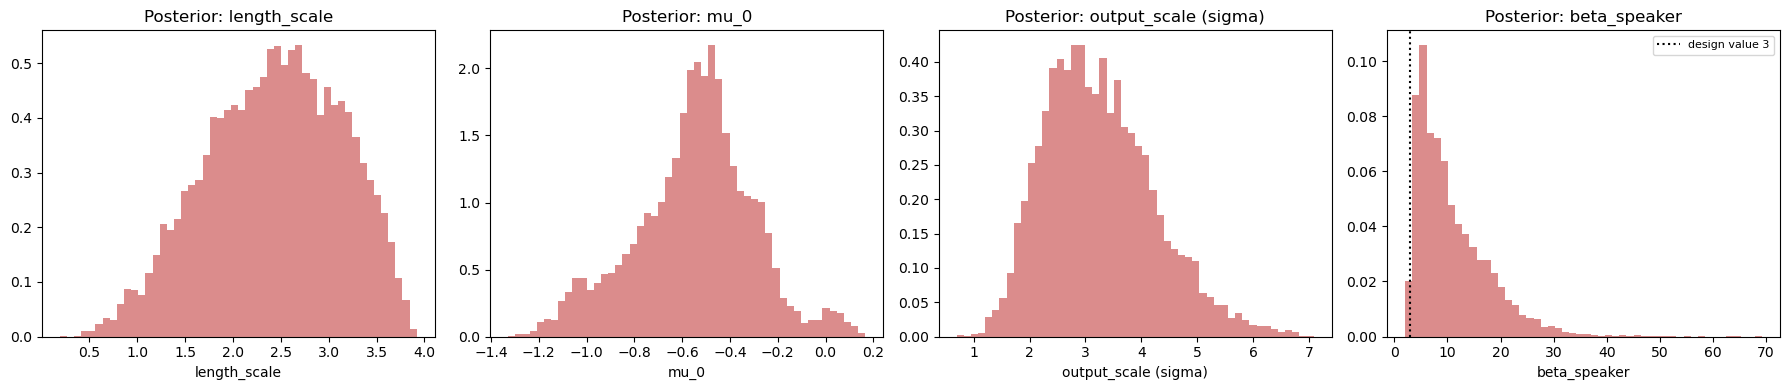

In [4]:
print(f"convergence={fit_f['convergence_status']}  evals={fit_f['func_count']}  "
      f"ELBO={fit_f['elbo']:.1f}  runtime={fit_f['runtime_s']/60:.0f} min")
def fmt(s): return f"{np.median(s):7.3f} [{np.percentile(s,2.5):.3f}, {np.percentile(s,97.5):.3f}]"
for name, key in [('length_scale', 'ls_samples'), ('mu_0', 'mu0_samples'),
                  ('sigma', 'sigma_samples'), ('beta_speaker', 'beta_samples')]:
    print(f"{name:<14}{fmt(fit_f[key])}")

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, key, name in zip(axes, ['ls_samples', 'mu0_samples', 'sigma_samples', 'beta_samples'],
                         ['length_scale', 'mu_0', 'output_scale (sigma)', 'beta_speaker']):
    ax.hist(fit_f[key], bins=50, density=True, color='indianred', alpha=0.7)
    if key == 'beta_samples':
        ax.axvline(inf.BETA_SPEAKER, color='k', ls=':', label='design value 3'); ax.legend(fontsize=8)
    ax.set_xlabel(name); ax.set_title(f'Posterior: {name}')
plt.tight_layout(); plt.show()

## 4. Forward pass at the posterior median

Per-feature predictions under two coherence readouts:

- **ratings-free** (`pred_prior`): Laplace mode of GP + utterances only — the model's pure
  prediction for each condition, never having seen the test ratings;
- **ratings-conditioned** (`pred_posterior`): mode of the full posterior including ratings
  (the study 9 section-5 convention).

Both use the fitted per-feature linking shapes at the posterior-median theta.

In [5]:
LS_B, MU_B, SIG_B, BETA_B = (float(np.median(fit_f['ls_samples'])), float(np.median(fit_f['mu0_samples'])),
                             float(np.median(fit_f['sigma_samples'])), float(np.median(fit_f['beta_samples'])))
print(f"Posterior median: ls={LS_B:.3f}, mu_0={MU_B:.3f}, sigma={SIG_B:.3f}, beta={BETA_B:.3f}")

_, shapes_f, cond_data_f = inf.total_log_lik_free_shapes(
    geom, responses_cond, LS_B, MU_B, SIG_B, beta_speaker=BETA_B, return_shapes=True)
mean_kl  = shapes_f[:, 0] / (shapes_f[:, 0] + shapes_f[:, 1])
mean_nkl = shapes_f[:, 2] / (shapes_f[:, 2] + shapes_f[:, 3])
np.savez_compressed(os.path.join(RESULTS_DIR, 'fitted-link-shapes.npz'),
                    shapes=shapes_f, feature_names=np.array(test_feature_names),
                    theta=np.array([LS_B, MU_B, SIG_B, BETA_B]))

pz1_prior = inf.prior_pz1_modes(geom, LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
pred_prior, pred_post = {}, {}
for c in CONDS:
    _, y_hat, ok = inf.laplace_log_Z(cond_data_f[c], LS_B, MU_B, SIG_B, beta_speaker=BETA_B)
    pz1_post = 1.0 / (1.0 + np.exp(-y_hat[:J]))
    pred_post[c]  = pz1_post * mean_kl + (1 - pz1_post) * mean_nkl
    pred_prior[c] = np.asarray(pz1_prior[c]) * mean_kl + (1 - np.asarray(pz1_prior[c])) * mean_nkl
    if not ok:
        print(f"  warning: {c} Laplace mode not cleanly converged")

pred_df = pd.DataFrame([
    {'condition': c, 'feature': f, 'empirical_mean': float(emp_cond[c][j]),
     'pz1_prior': float(pz1_prior[c][j]),
     'pred_prior': float(pred_prior[c][j]), 'pred_posterior': float(pred_post[c][j])}
    for c in CONDS for j, f in enumerate(test_feature_names)])
pred_df.to_csv(os.path.join(RESULTS_DIR, 'predictions.csv'), index=False)
print(f"saved per-feature predictions to {RESULTS_DIR}/predictions.csv")

Posterior median: ls=2.468, mu_0=-0.530, sigma=3.151, beta=9.015


saved per-feature predictions to results/study6-vbmc-laplace-beta/predictions.csv


## 5. Predicted vs empirical prevalence per condition

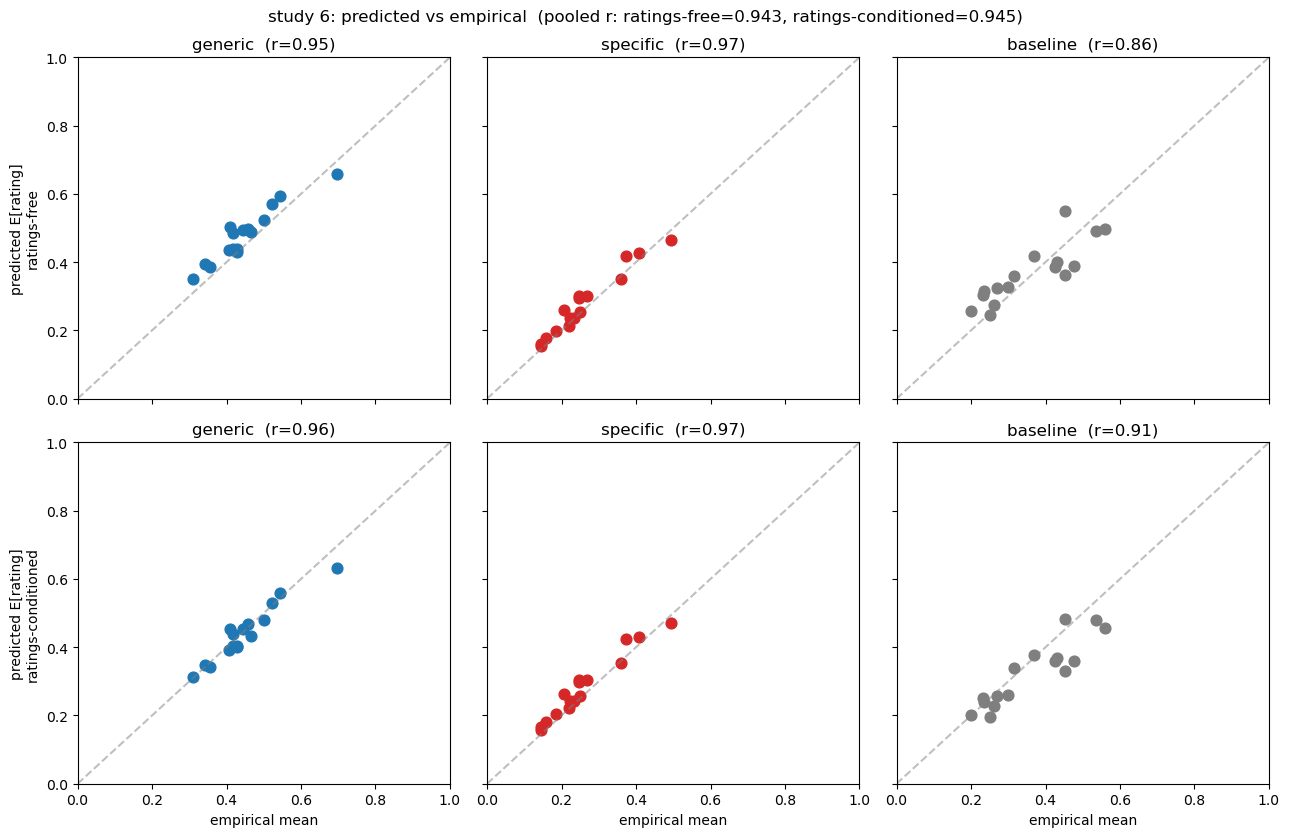

In [6]:
ccol = {'generic': 'tab:blue', 'specific': 'tab:red', 'baseline': 'tab:gray'}
fig, axes = plt.subplots(2, 3, figsize=(13, 8.5), sharex=True, sharey=True)
for row, (pred, lbl) in enumerate([(pred_prior, 'ratings-free'),
                                   (pred_post, 'ratings-conditioned')]):
    for ax, c in zip(axes[row], CONDS):
        ax.scatter(emp_cond[c], pred[c], s=60, color=ccol[c])
        ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        r = np.corrcoef(emp_cond[c], pred[c])[0, 1]
        ax.set_title(f"{c}  (r={r:.2f})")
        if row == 1: ax.set_xlabel('empirical mean')
    axes[row][0].set_ylabel(f"predicted E[rating]\n{lbl}")
cat = lambda pred: np.concatenate([pred[c] for c in CONDS])
r_prior = np.corrcoef(cat(emp_cond), cat(pred_prior))[0, 1]
r_post  = np.corrcoef(cat(emp_cond), cat(pred_post))[0, 1]
fig.suptitle(f'study 6: predicted vs empirical  (pooled r: ratings-free={r_prior:.3f}, '
             f'ratings-conditioned={r_post:.3f})')
plt.tight_layout(); plt.show()

## 6. Condition means

The headline manipulation check: generic training should raise rated prevalence of the
(unmentioned) test features relative to baseline, specific training should lower it.

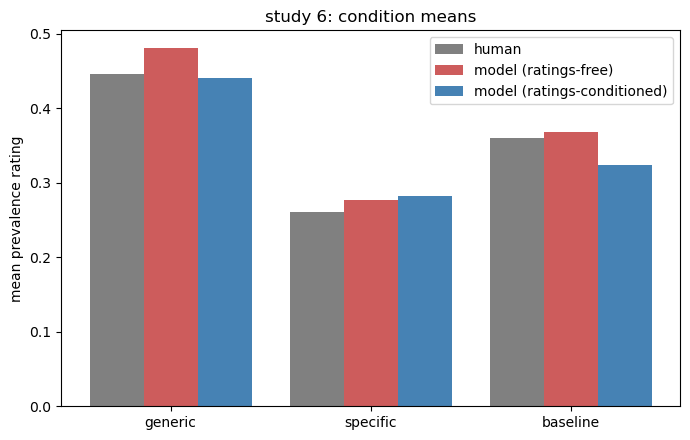

In [7]:
x = np.arange(len(CONDS)); w = 0.27
emp_m = [float(np.array(responses_cond[c]).mean()) for c in CONDS]
pri_m = [float(pred_prior[c].mean()) for c in CONDS]
pos_m = [float(pred_post[c].mean()) for c in CONDS]
plt.figure(figsize=(7, 4.5))
plt.bar(x - w, emp_m, w, label='human', color='gray')
plt.bar(x,     pri_m, w, label='model (ratings-free)', color='indianred')
plt.bar(x + w, pos_m, w, label='model (ratings-conditioned)', color='steelblue')
plt.xticks(x, CONDS); plt.ylabel('mean prevalence rating'); plt.legend()
plt.title('study 6: condition means'); plt.tight_layout(); plt.show()

## 7. GP coherence field per condition at the posterior median

Same visualization as `plot-gp-coherence-field.ipynb` / study 9 section 6: contours are the
ratings-free GP-conditional `P(kind-linked)` given each condition's training utterances, at the
posterior-median theta. Generic-trained features pull the field up (dark circles), specific-trained
features pull it down (red X's), baseline is the bare prior `sigmoid(mu_0)`. Test features are
colored by their empirical mean rating on the same 0-1 color scale.

Top row: absolute 0-1 scale (comparable across conditions). Bottom row: per-panel autoscaled
contours — with the fitted length scale (~2.5) far exceeding the feature-cloud diameter (~0.8)
the field is nearly flat within a condition, so spatial structure only shows up once autoscaled.

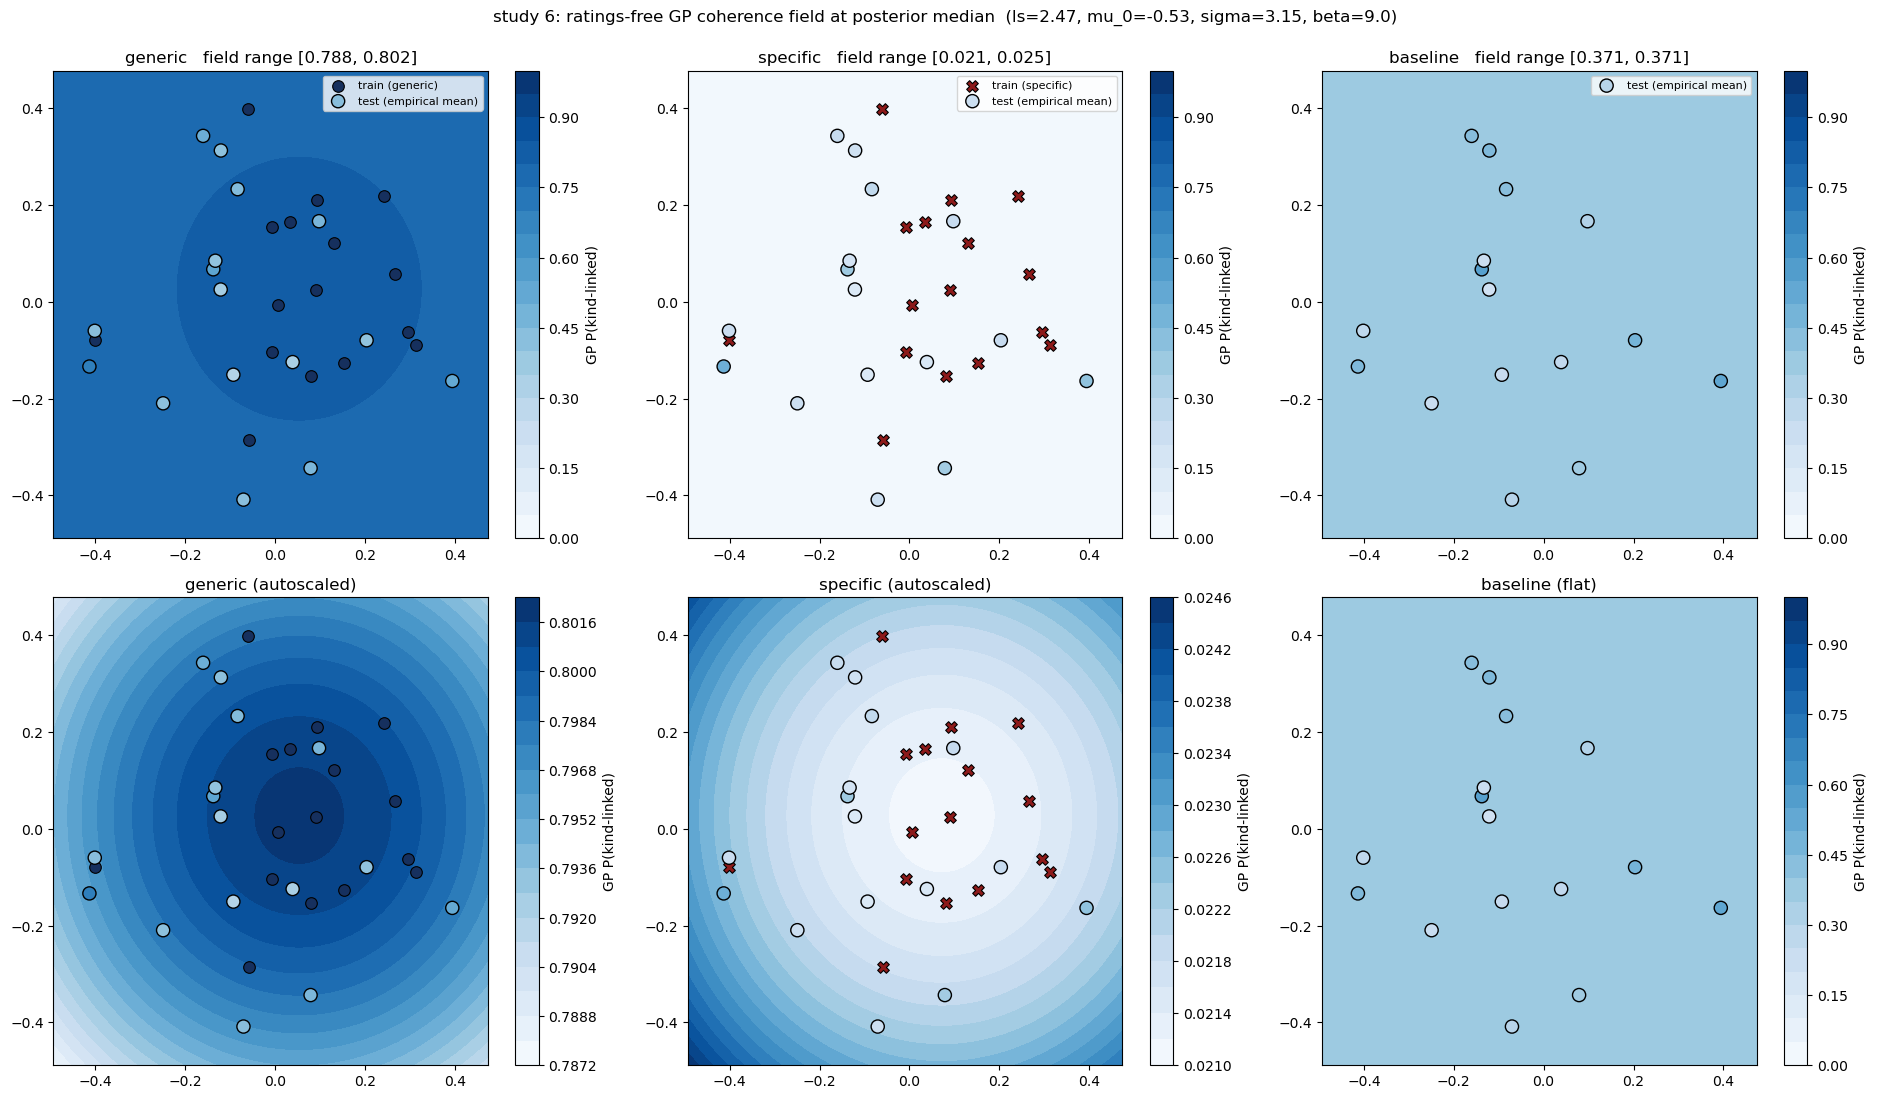

generic   field at test features: mean=0.799  range [0.796, 0.801]
specific  field at test features: mean=0.022  range [0.021, 0.023]
baseline  field at test features: mean=0.371  range [0.371, 0.371]


In [8]:
all_x = np.vstack([np.array(geom['x_test'])] +
                  [np.array(geom['x_train_cond'][c]) for c in CONDS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

fields = {c: inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, X_grid,
                                    beta_speaker=BETA_B).reshape(gx.shape) for c in CONDS}

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for col, c in enumerate(CONDS):
    field = fields[c]
    for row in range(2):
        ax = axes[row, col]
        flat = field.max() - field.min() < 1e-6   # baseline: no utterances -> exactly flat
        levels = np.linspace(0, 1, 21) if (row == 0 or flat) else 20
        cs = ax.contourf(gx, gy, field, levels=levels, cmap='Blues')
        cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

        x_tr = np.array(geom['x_train_cond'][c])
        if len(x_tr):
            u = np.array(geom['u_train_cond'][c])
            style = {0: ('o', '#16305e', 'train (generic)'),
                     1: ('X', '#8c1a1a', 'train (specific)')}
            for uu in np.unique(u):
                m = u == uu
                ax.scatter(x_tr[m, 0], x_tr[m, 1], s=70, marker=style[uu][0],
                           color=style[uu][1], edgecolor='k', linewidth=0.8,
                           zorder=3, label=style[uu][2])
        ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=90, c=emp_cond[c],
                   cmap='Blues', vmin=0, vmax=1, edgecolor='k', zorder=4,
                   label='test (empirical mean)')
        ax.set_title(f"{c}   field range [{field.min():.3f}, {field.max():.3f}]"
                     if row == 0 else (f"{c} (flat)" if flat else f"{c} (autoscaled)"))
        if row == 0:
            ax.legend(fontsize=8, loc='upper right')
fig.suptitle(f'study 6: ratings-free GP coherence field at posterior median  '
             f'(ls={LS_B:.2f}, mu_0={MU_B:.2f}, sigma={SIG_B:.2f}, beta={BETA_B:.1f})',
             y=0.995)
plt.tight_layout(); plt.show()

for c in CONDS:
    pz1_test = inf.gp_coherence_field(geom, c, LS_B, MU_B, SIG_B, x_test_np, beta_speaker=BETA_B)
    print(f"{c:<9} field at test features: mean={pz1_test.mean():.3f}  "
          f"range [{pz1_test.min():.3f}, {pz1_test.max():.3f}]")

## 8. Model vs data in the Exp-1a format (+ export for the R pipeline)

Same visual language as the slides (`analyses/study 6/study6_analysis.Rmd`):   
x = model prevalence,  
y = human prevalence,  
small dots = the 48 condition x feature cells,  
large dots = condition means,   
r² = squared correlation across cells.  

This GP + RSA model is the analog of the **pragmatic listener**
(the specific-condition suppression comes from speaker-based pragmatic reasoning); the model
prevalences are the **ratings-free** forward predictions.

Also exports `df_gp_feature.csv` — one row per (condition, feature) with the R pipeline's
snake_case feature names — schema-compatible with the Rmd's `df_prag_feature.csv` import, so
the same `glmmTMB(prevalence ~ model_mean + (1|participant))` AIC/BIC comparison can be run
against the base / literal / pragmatic variants.

Caveat for the comparison: our theta (and beta) were FIT to these ratings, while their model
means may come from forward simulation at hand-set parameters — worth stating alongside AIC/BIC.

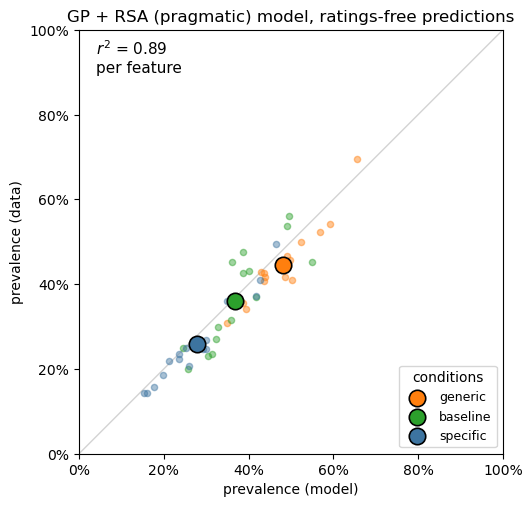

  generic   r2 per feature (within condition) = 0.90
  baseline  r2 per feature (within condition) = 0.73
  specific  r2 per feature (within condition) = 0.94
saved df_gp_feature.csv to results/study6-vbmc-laplace-beta/ and ../scratch/study 6/


In [9]:
COND_ORDER = ['generic', 'baseline', 'specific']
COND_COLOR = {'generic': 'tab:orange', 'baseline': 'tab:green', 'specific': '#3d74a0'}

fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.plot([0, 1], [0, 1], color='lightgray', lw=1, zorder=0)
for c in COND_ORDER:
    ax.scatter(pred_prior[c], emp_cond[c], s=20, color=COND_COLOR[c], alpha=0.45, zorder=2)
    ax.scatter(pred_prior[c].mean(), emp_cond[c].mean(), s=140, color=COND_COLOR[c],
               edgecolor='k', linewidth=1.2, zorder=3, label=c)
allx = np.concatenate([pred_prior[c] for c in COND_ORDER])
ally = np.concatenate([emp_cond[c] for c in COND_ORDER])
r2 = np.corrcoef(allx, ally)[0, 1] ** 2
ax.text(0.04, 0.90, f"$r^2$ = {r2:.2f}\nper feature", transform=ax.transAxes, fontsize=11)
ticks = np.linspace(0, 1, 6)
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels([f'{t:.0%}' for t in ticks]); ax.set_yticklabels([f'{t:.0%}' for t in ticks])
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_xlabel('prevalence (model)'); ax.set_ylabel('prevalence (data)')
ax.legend(title='conditions', fontsize=9, loc='lower right')
ax.set_title('GP + RSA (pragmatic) model, ratings-free predictions')
plt.tight_layout(); plt.show()

for c in COND_ORDER:
    r2c = np.corrcoef(pred_prior[c], emp_cond[c])[0, 1] ** 2
    print(f"  {c:<9} r2 per feature (within condition) = {r2c:.2f}")

# export for the R pipeline (schema of model/scratch/study 6/df_prag_feature.csv:
# columns condition, feature, prevalence; the Rmd averages over rows per cell,
# so one row per condition x feature carrying the model mean is equivalent)
col_of_feature = {v: k for k, v in s68.STUDY6_COL_TO_FEATURE.items()}
export = pd.DataFrame([
    {'condition': c, 'feature': col_of_feature[f], 'prevalence': float(pred_prior[c][j])}
    for c in COND_ORDER for j, f in enumerate(test_feature_names)])
export.to_csv(os.path.join(RESULTS_DIR, 'df_gp_feature.csv'), index=False)
scratch_dir = os.path.join('..', 'scratch', 'study 6')
os.makedirs(scratch_dir, exist_ok=True)
export.to_csv(os.path.join(scratch_dir, 'df_gp_feature.csv'), index=False)
print(f"saved df_gp_feature.csv to {RESULTS_DIR}/ and {scratch_dir}/")